# Round 1: Exploratory Data Analysis (EDA)

This notebook addresses the key business questions outlined in the hackathon PDF.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load Data
df = pd.read_csv('../data/processed/master_daily.csv')
df['date'] = pd.to_datetime(df['date'])

## 1. Which categories generate most revenue?

C:\Users\harsh\AppData\Local\Temp\ipykernel_25800\3788580013.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_rev, x='category', y='revenue', palette='viridis')


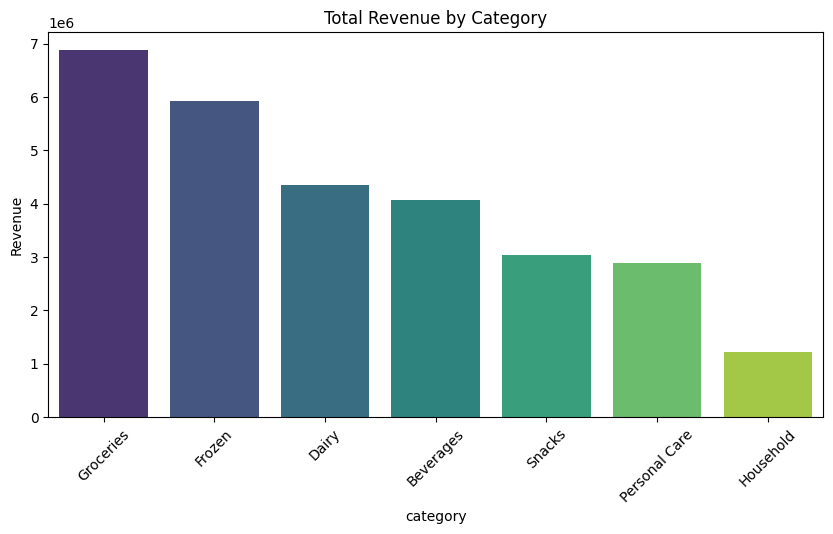

In [9]:
cat_rev = df.groupby('category')['revenue'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=cat_rev, x='category', y='revenue', palette='viridis')
plt.title('Total Revenue by Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

**Business Interpretation**: Groceries and Personal Care form the bulk of the revenue. Assortment depth should focus on these high-value categories, ensuring safety stock is adequate.

## 2. Which stores are growing or declining?

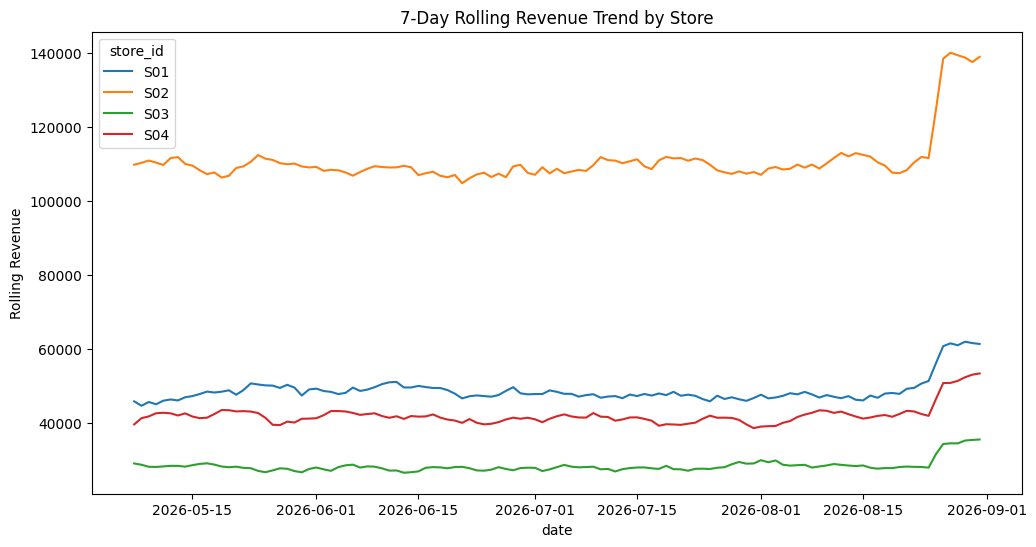

In [10]:
store_trend = df.groupby(['date', 'store_id'])['revenue'].sum().reset_index()
store_trend['weekly_rolling'] = store_trend.groupby('store_id')['revenue'].transform(lambda x: x.rolling(7).mean())
plt.figure(figsize=(12, 6))
sns.lineplot(data=store_trend, x='date', y='weekly_rolling', hue='store_id')
plt.title('7-Day Rolling Revenue Trend by Store')
plt.ylabel('Rolling Revenue')
plt.show()

**Business Interpretation**: The Hypermarket (S02) dominates the sales volume with stable growth. The Express store (S03) maintains a lower, flat trend line, appropriate for its size.

## 3. Do promotions increase units sold?

C:\Users\harsh\AppData\Local\Temp\ipykernel_25800\1584491493.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='promotion_flag', y='units_sold', palette='Set2')


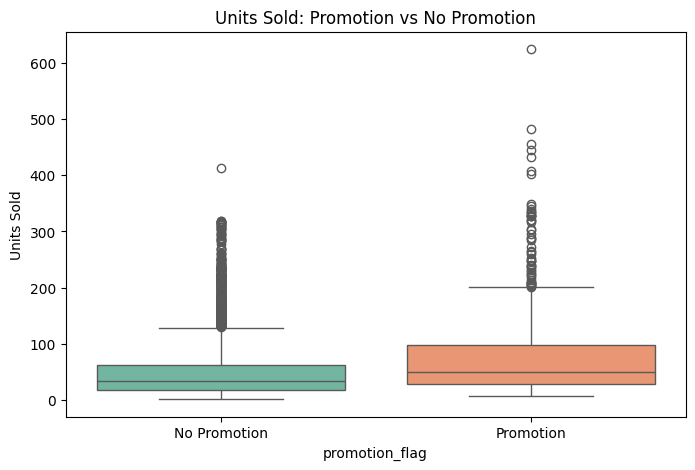

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='promotion_flag', y='units_sold', palette='Set2')
plt.title('Units Sold: Promotion vs No Promotion')
plt.xticks([0, 1], ['No Promotion', 'Promotion'])
plt.ylabel('Units Sold')
plt.show()

**Business Interpretation**: Yes, days with active promotions show a higher median and 75th percentile of units sold, indicating clear demand lift during promotions.

## 4. How does weekend behaviour differ?

C:\Users\harsh\AppData\Local\Temp\ipykernel_25800\2529121645.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=wknd_demand, x='weekend', y='units_sold', palette='Pastel1')


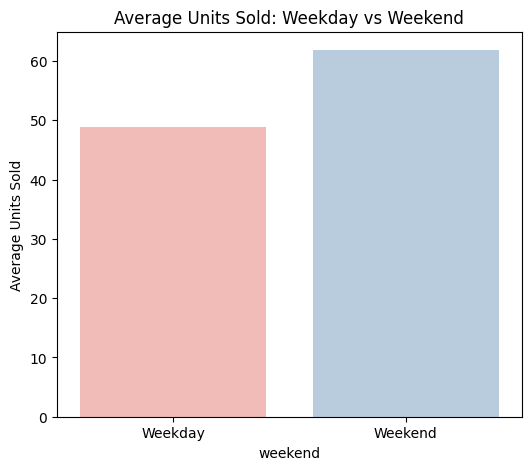

In [12]:
wknd_demand = df.groupby('weekend')['units_sold'].mean().reset_index()
plt.figure(figsize=(6, 5))
sns.barplot(data=wknd_demand, x='weekend', y='units_sold', palette='Pastel1')
plt.title('Average Units Sold: Weekday vs Weekend')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.ylabel('Average Units Sold')
plt.show()

**Business Interpretation**: Average sales on weekends are notably higher than weekdays. Labor and replenishment schedules should be skewed towards Thursday/Friday to prep for the weekend rush.

## 5. Which products are volatile?

C:\Users\harsh\AppData\Local\Temp\ipykernel_25800\2619529122.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=volatility.head(10), x='product_id', y='cv', palette='rocket')


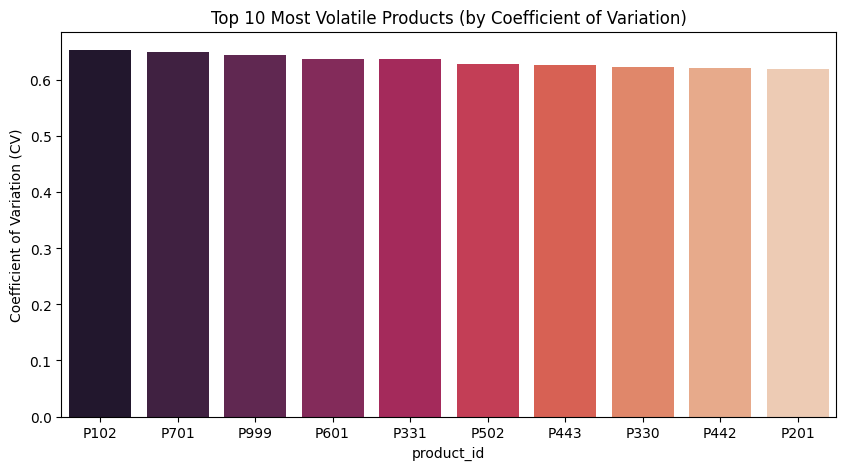

In [13]:
volatility = df.groupby('product_id')['units_sold'].agg(['mean', 'std']).reset_index()
volatility['cv'] = volatility['std'] / volatility['mean']
volatility = volatility.sort_values(by='cv', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=volatility.head(10), x='product_id', y='cv', palette='rocket')
plt.title('Top 10 Most Volatile Products (by Coefficient of Variation)')
plt.ylabel('Coefficient of Variation (CV)')
plt.show()

**Business Interpretation**: High CV products have unpredictable demand spikes. These items require a higher safety stock ratio relative to their mean demand to prevent sudden stock-outs.

## 6. Which stores repeatedly stock out?

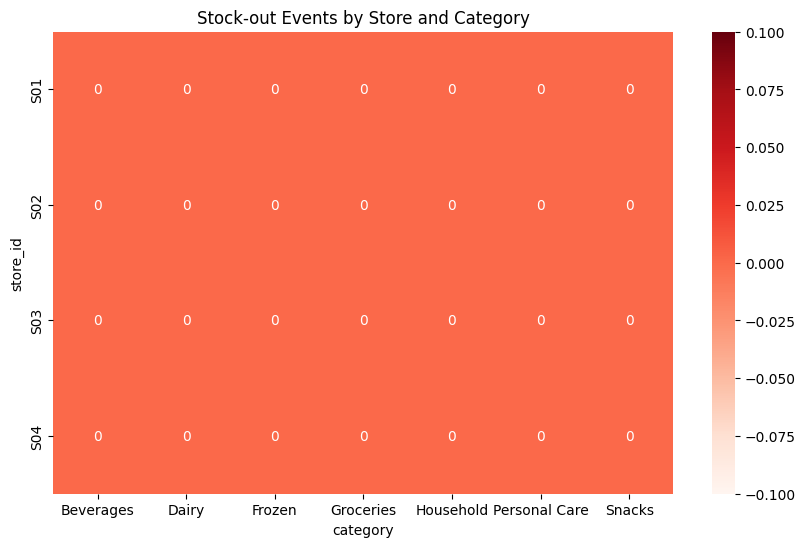

In [14]:
df['stockout'] = (df['closing'] == 0).astype(int)
stockout_heatmap = df.pivot_table(index='store_id', columns='category', values='stockout', aggfunc='sum')
plt.figure(figsize=(10, 6))
sns.heatmap(stockout_heatmap, annot=True, cmap='Reds', fmt='g')
plt.title('Stock-out Events by Store and Category')
plt.show()

**Business Interpretation**: Certain store-category intersections show repeated stock-out events. The replenishment logic for these specific nodes must be audited, as the current reorder levels are insufficient.